In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [58]:
df=pd.read_csv("1-studyhours.csv")

In [59]:
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study Hours  33 non-null     float64
 1   Exam Score   33 non-null     float64
dtypes: float64(2)
memory usage: 660.0 bytes


In [61]:
df.describe()

,Study Hours,Exam Score
count,33.000000,33.000000
mean,15.772727,74.612121
std,7.608723,18.711206
min,3.000000,40.000000
25%,9.600000,58.500000
50%,17.400000,78.800000
75%,21.300000,90.800000
max,30.000000,100.000000


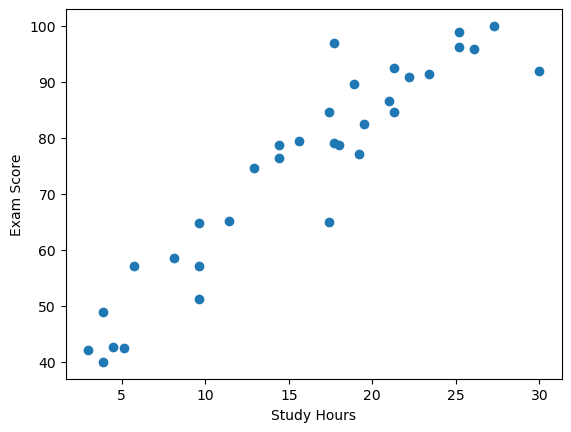

In [62]:
plt.scatter(df['Study Hours'],df['Exam Score'])
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.show()

In [63]:
# independet and dependent features
X=df[['Study Hours']]
y=df['Exam Score']

In [64]:
type(X)

pandas.core.frame.DataFrame

In [65]:
type(y)

pandas.core.series.Series

In [66]:
# test - train split

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [69]:
y_train

18     64.9
1      57.1
2      42.7
32     89.6
6      77.1
3      65.1
29     82.4
26     64.8
9      84.6
4      78.7
28     79.1
10     92.4
27     79.5
13    100.0
17     74.7
15     97.0
22     76.5
31     96.2
11     95.9
7      90.8
0      40.0
23     42.2
5      78.8
12     92.0
21     58.5
8      99.0
Name: Exam Score, dtype: float64

In [70]:
y_test

25    42.4
14    86.6
30    91.5
16    57.2
24    51.2
20    49.0
19    84.7
Name: Exam Score, dtype: float64

In [71]:
# standardize the data set

In [72]:
from sklearn.preprocessing import StandardScaler

In [73]:
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [74]:
#balanced feat
#efficient gradien descentt
#l1, l2

In [75]:
scaler=StandardScaler()

In [76]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test) #fit -> data leakage (verinin sızmaması , train'in testle ilgili hiçbir şey bilmemesi)

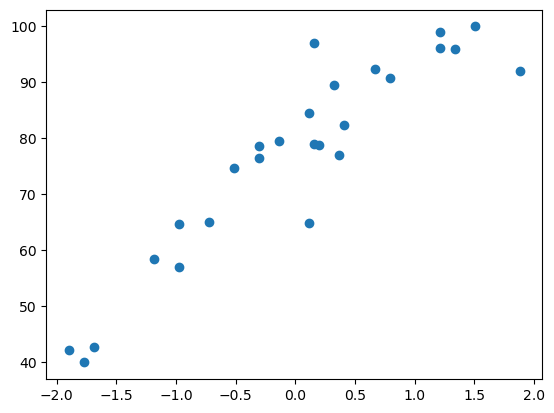

In [77]:
plt.scatter(X_train,y_train)
plt.show()

In [78]:
from sklearn.linear_model import LinearRegression

In [79]:
regression = LinearRegression()

In [80]:
regression.fit(X_train,y_train)

LinearRegression()

In [81]:
print("Coefficient : ",regression.coef_)
print("Intercept : ",regression.intercept_)

Coefficient :  [16.17860223]
Intercept :  76.9076923076923


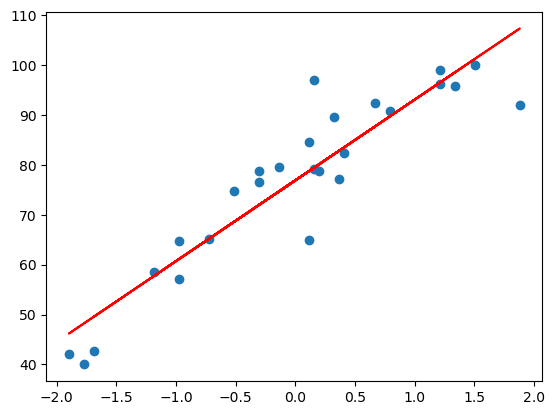

In [82]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),"r")
plt.show()

In [83]:
# X=20, y=?

In [84]:
regression.predict([[20]])

array([400.47973694])

In [85]:
scaler.transform([[20]])

C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.48200796]])

In [86]:
regression.predict(scaler.transform([[20]]))

C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([84.70590731])

In [87]:
regression.predict(scaler.transform([[10]]))

C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([62.05187491])

In [88]:
# prediction with test data

In [89]:
y_pred_test=regression.predict(X_test)

In [90]:
y_test

25    42.4
14    86.6
30    91.5
16    57.2
24    51.2
20    49.0
19    84.7
Name: Exam Score, dtype: float64

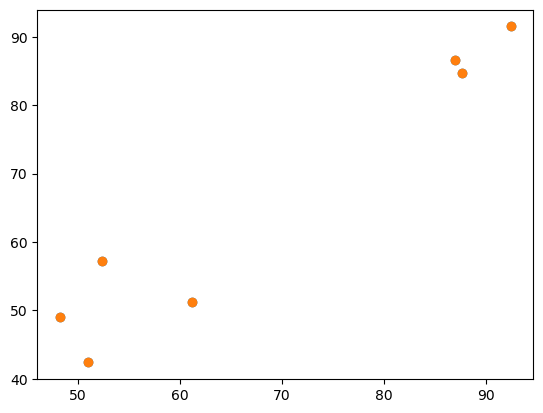

In [93]:
plt.scatter(y_pred_test, y_test)
plt.show()

In [95]:
### Performance metrics

from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

In [97]:
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

29.45839048833392
4.054868128856142
5.427558427906043


In [99]:
score=r2_score(y_test,y_pred_test)

In [100]:
score

0.9196596206825491

In [101]:
#adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.903591544819059